# COGS 108 - Olympic Athletes Physical Attributes and Performance

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Hieu Pham
- Rishi Munagala
- Mingyang Chen
- Henry Than

# Abstract

In this project, we aim to determine whether there is a correlation among physical attributes of an Olympic athlete and their performance for an event. We choose to focus on track sporting events and use athlete height, weight, and BMI (which was calculated) as the measures for physical attributes. The dataset provided the medal earned (Gold,Silver,Bronze) or N/A if they did not which was used as our primary performance metric. Since there was no numerical data for performance metrics such as track times, we used the medals and assigned then numerical weights as substituion for this. 

After cleaning the data to focus on these main attributes and track sporting events, we performed OLS regression to determine any linear relationships between these physical features and their achievements. We performed analysis using the main three features of height, weight, and BMI. To do this we performed linear regression analysis and multiregression analysis. From there we decided to dig deeper into the data analysis by considering within whether there the correlations can be influenced by hurdles vs sprints, males vs females, or short and long distance.

 After performing our analysis, we found a slightly positive correlation between physical attributes and their performance for the event. Even though it was a slight correlation, this study laid foundational groundwork for future studies to perform analysis on finding the best physical attribute correlator to performance. We found some interesting results from the interdependencies within the variables such as how short and long term distances can play an impact on this style of study.

# Research Question

Is there a relationship between the physical attributes (height, weight, sex) of Olympic track runners and their performance metrics (Medals)? Does this differ among subcategory events (sprints, hurdles, etc.)?


## Background and Prior Work

In the realm of competitive sports, running is one of the most direct and simple representations of an athlete's physical capabilities. Countless athletes around the world participate in this sport, and only the best of the best make it to the Olympics. The Olympics serves as a showcase for the most capable athletes in the world, representing their own respective countries. The goal of this project is to find a relationship between olympic track runners’ physical attributes and their performance in their event(s). We’ve determined that height, weight, age, and sex were valid physical characteristics when conducting this study and we have defined placement in events as their performance metric (e.g. Gold, Silver, bronze).

One reference that will be relevant to our project is helping to understand the correlations between these physical attributes and performance. This study examines how height, body, mass, and a few other factors can relate to performance among Japanese college athletes on the different track and field results (Aikawa et al). In a sense, this is similar to what we are trying to analyze by also focusing on the different track and field results but expanding it to include women and focus on olympic athletes around the world. The study found that there was a correlation between some “body composition indicators” and athletic performance. Thus this is leading use a great starting point in that there can potentially be correlations but to now expand it further with Olympic information. The use of scatter plots and regression analysis to understand correlations will be a useful methodology for understanding and assessing our hypothesis for our own study.

Another study that will be useful for understanding similar means approaches to study correlations is a review of analysis of these physical performance measures such as age, height, and weight for adults. This study was a little different in that they actually performed the test on recruited men and women. They found that muscle strength and mobility decline with age over time (Samson et al.) This is useful for our study as we are also assessing the performance based on the factor of age. Here in this study proves that there is a declining relationship which also leads to formulating our understanding around this prior knowledge. Similarly in this study we see that scatter plots were a main form of trying to correlate the data and draw conclusions from which is what we will also use in our study.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Sasai, H., Kataoka, T., Naito, M., Sunagawa, M., Wakisaka, M., Fujita, H., & Eto, M. (2000). Relationship of height, body mass, muscle mass, fat mass, and the percentage of fat with athletic performance in male Japanese college sprinters, distance athletes, jumpers, throwers, and decathletes. *Journal of Sports Science*, 18(4), 275–282. https://doi.org/10.1080/026404100365034 
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Yuki Aikawa, Mayu Murata, Naomi Omi. (2020). Relationship of height, body mass, muscle mass, fat mass, and the percentage of fat with athletic performance in male Japanese college sprinters, distance athletes, jumpers, throwers, and decathletes. *The Journal of Physical Fitness and Sports Medicine*, 9(1). https://doi.org/10.7600/jpfsm.9.7


# Hypothesis


We predict that there is a positive correlation between physical attributes of Olympic track runners and their performance. We are going to limit this prediction to standard track events such as sprints, semi-long distance, and hurdles. And performance metric will be determined as number of medals won, with higher medals holding more weight.

### What leads to our hypothesis?

From the background research, we saw a potentially positive correlation between some of the attributes we are examining and the performance of athletes. Additionally, based on our personal knowledge, we believe that athletes with greater physical attributes such as height and weight should have advantages than others. To make our analysis more accurate, we will also explore the BMI (Body Mass Index) of athletes, which is a metric involving both height and weight. 

# Data

An ideal dataset that can answer our research question would be a dataset that includes physical attributes of athletes such as height and weight with a performance metric such as track times for the specific events along with how they did in terms of medal won. Having these information can be useful towards making better analysis on how the physical features can play a role in determining an individual's success and performance factor.

## Dataset Overview
  - Dataset Name: 120 years of Olympic history: athletes and results
  - Link to the dataset: https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results/data 
  - Number of observations: 271,117
  - Number of variables: 15

The dataset that we will use to help answer our question is this dataset that details the information data on athletes and medal results from Athens 1896 to Rio 2016 Olympic events. It contains bio information of the athletes such as name, sex, age, height, and weight along with their success in medals of either Gold, Silver, Bronze, or N/A. We can make use of the physical attributes and medal winning to assess correlations. With the data as is and without any cleaning, there are 271,117 observations. This is a lot and makes sense as it contains 120 years of Olympic athlete's data. However, since our focus is to look specifically at track results we will clean the dataset so that it includes only those of our interest.

## Data Cleaning

In this section, we will be using some basic data cleaning techniques learned from class to obtain a usable dataset for our analysis.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import patsy
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import ttest_ind, chisquare, normaltest

We first remove some of the columns that are not needed for our analysis. Then, by looking at the Event column, we filter our dataset so that it includes only rows with track events that we are interested in. 

In [2]:
def filter_track(string):
    string = string.lower()
    string = string.strip()
    if 'athletics' in string and 'metres' in string:
        if all(s not in string for s in ['relay', 'steeplechase', 'walk', 'kilometres', '10,000', '5,000', '3,500', '3,000']):
            return string
    else:
        return np.nan

In [3]:
olympics = pd.read_csv('athlete_events.csv')

# Drop unnecessary columns
columns_to_remove = ['ID', 'Name', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Age']
olympics = olympics.drop(columns=columns_to_remove)

# Drop rows with non-track events and null height or weight
olympics['Event'] = olympics['Event'].apply(filter_track)
olympics.dropna(subset=['Event', 'Height', 'Weight'], inplace=True)

Here, we also calculate the BMI based on height and weight of athletes. After that, we map each value in the Medal column to a numerical value so that we can use it as the performance metric for our analysis.

In [4]:
# Calculate and add BMI column
olympics['BMI'] = olympics['Weight'] / (olympics['Height'] / 100) ** 2

# Change categorical variables to have numerical mapping
medal_mapping = {np.nan: 0, 'Bronze': 1, 'Silver': 2, 'Gold': 3}
olympics['Medal'] = olympics['Medal'].replace(medal_mapping)

# Reset index
olympics.reset_index(drop=True, inplace=True)

After cleaning, we have a dataset with 11050 rows, which is sufficient for our analysis later. Here's some basic description of our cleaned dataset. As we can see below, it only contains rows with standard track events such as sprints, semi-long distance, and hurdles.

In [5]:
olympics.shape

(11050, 6)

In [6]:
olympics.head()

,Sex,Height,Weight,Event,Medal,BMI
0,M,187.0,76.0,"athletics men's 1,500 metres",0,21.733535
1,M,182.0,67.0,"athletics men's 1,500 metres",0,20.227026
2,M,182.0,67.0,"athletics men's 1,500 metres",1,20.227026
3,M,190.0,80.0,athletics men's 110 metres hurdles,0,22.160665
4,M,168.0,60.0,athletics men's 100 metres,0,21.258503


In [7]:
olympics.describe()

,Height,Weight,Medal,BMI
count,11050.000000,11050.000000,11050.000000,11050.000000
mean,175.293846,66.199502,0.161086,21.448739
std,8.571247,9.646707,0.593755,1.900478
min,142.000000,40.000000,0.000000,14.506173
25%,169.000000,59.000000,0.000000,20.177149
50%,175.000000,66.000000,0.000000,21.385936
75%,182.000000,73.000000,0.000000,22.678899
max,201.000000,102.000000,3.000000,32.466181


In [8]:
olympics['Event'].value_counts()

Event
athletics men's 100 metres              1430
athletics men's 200 metres              1133
athletics men's 400 metres              1107
athletics men's 800 metres              1030
athletics men's 1,500 metres             926
athletics women's 100 metres             921
athletics men's 110 metres hurdles       710
athletics men's 400 metres hurdles       702
athletics women's 200 metres             702
athletics women's 400 metres             571
athletics women's 800 metres             522
athletics women's 1,500 metres           419
athletics women's 100 metres hurdles     410
athletics women's 400 metres hurdles     301
athletics women's 80 metres hurdles      151
athletics men's 60 metres                 10
athletics men's 200 metres hurdles         5
Name: count, dtype: int64

We further split our dataset based on gender and distance of the event.

In [9]:
olympics_m = olympics[olympics.Sex == 'M']
olympics_f = olympics[olympics.Sex == 'F']
olympics_hurdles = olympics[olympics['Event'].str.contains('hurdles')]
olympics_run = olympics[~olympics['Event'].str.contains('hurdles')]

olympics_m.shape, olympics_f.shape, olympics_hurdles.shape, olympics_run.shape

((7053, 6), (3997, 6), (2279, 6), (8771, 6))

In [10]:
def split_distance(string, dist):
    if dist == 'long':
        if '1,500' in string or '800' in string:
            return string
        else:
            return np.nan
    if dist == 'short':
        if '1,500' in string or '800' in string:
            return np.nan
        else:
            return string

In [11]:
olympics_short = olympics[olympics['Event'].apply(lambda x: split_distance(x, 'short')).notnull()]
olympics_long = olympics[olympics['Event'].apply(lambda x: split_distance(x, 'long')).notnull()]

olympics_short.shape, olympics_long.shape

((8153, 6), (2897, 6))

# Results

## Exploratory Data Analysis

Before we begin our analysis, we want to make clear that our performance metric will be based on the medals that our athletes earn. Above we applied weights to the three different types of medals, 1 point for bronze, 2 points for silver, 3 points for gold, and 0 points if no medal is earned. We want to see if there is any correlation between the physical attributes of our athletes, and the number of 'points' they earn.

### Regression Analysis of Height over Performance

We start our analysis by exploring the relationship between height and performance. First we take a look at the overall distribution of height across all of our athletes in our cleaned dataset. We can see that our histplot shows a somewhat normal distribution across all athletes, with our minimum height being 152 cm and our max height being 201 cm.

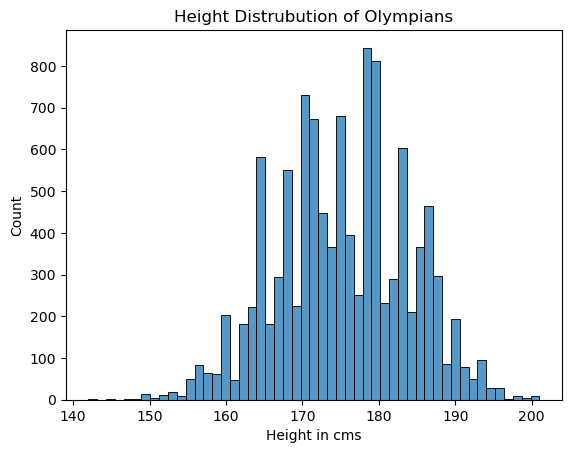

In [12]:
sns.histplot(olympics['Height'])

plt.xlabel('Height in cms')
plt.ylabel('Count')
plt.title('Height Distrubution of Olympians')
plt.show()

Before we run our OLS regression, we want to start by generating a linear regreassion plot to visualize any correlation between medal and height of our athletes. We place Height on our x-axis and Medal on our y-axis.

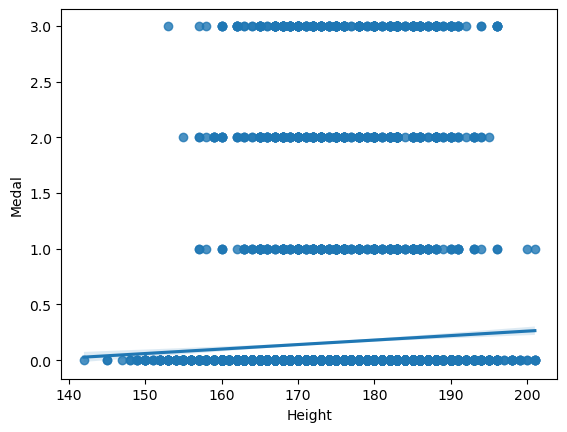

In [13]:
sns.regplot(x='Height', y='Medal', data=olympics);

From the graph, we notice that those winning medals have height near the center. But overall, it seems there may be a slight positive correlation. Let's check if this is true. From our regression results below, we can see that the coefficient for height is 0.004, meaning that for every increase of 1 cm in an athlete's height, their 'points' go up by 0.004. So, there is a positive correlation between height and performance. 

In [14]:
outcome, predictors = patsy.dmatrices('Medal ~ Height', olympics)
model = sm.OLS(outcome, predictors)
res_h = model.fit()
print(res_h.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     37.49
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           9.51e-10
Time:                        20:58:59   Log-Likelihood:                -9899.8
No. Observations:               11050   AIC:                         1.980e+04
Df Residuals:                   11048   BIC:                         1.982e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5451      0.115     -4.720      0.0

### Regression Analysis of Weight over Performance

We continue to examine the relationship between weight and performance. As usual, we start by visualizing the overall distribution of weight across all athletes. Here, we see a somewhat normal distribution with the majority of the atchletes being in that 60 to 70 kgs range. 

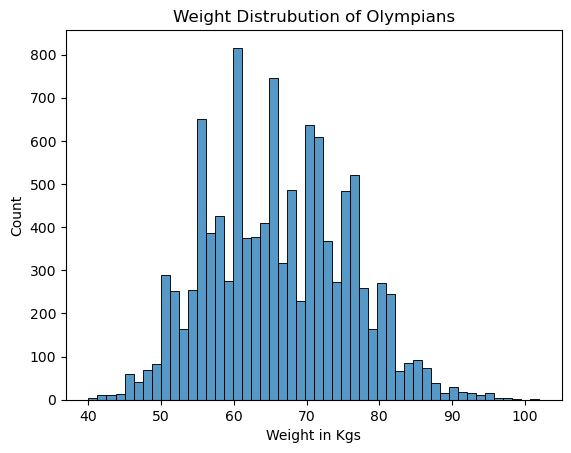

In [15]:
sns.histplot(olympics['Weight'])

plt.xlabel('Weight in Kgs')
plt.ylabel('Count')
plt.title('Weight Distrubution of Olympians')
plt.show()

Again, we generate a linear regression plot to see if there is any correlation between weight and performance. Looking at the plot, we notice the weight of those winning medals are pretty evenly spread out. But overall, the correlation seems to be slightly positive.

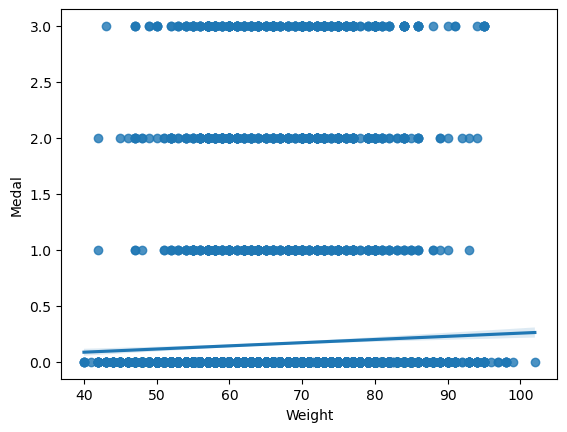

In [16]:
sns.regplot(x='Weight', y='Medal', data=olympics);

From our regression results below, we can see the coefficient for weight is 0.0028, meaning that for every increase of 1 kg in an athlete's weight, their 'points' go up by 0.0028. Hence, there seems to be a positive correlation between weight and performance. 

In [17]:
outcome, predictors = patsy.dmatrices('Medal ~ Weight', olympics)
model = sm.OLS(outcome, predictors)
res_1 = model.fit()
print(res_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     23.50
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           1.26e-06
Time:                        20:58:59   Log-Likelihood:                -9906.8
No. Observations:               11050   AIC:                         1.982e+04
Df Residuals:                   11048   BIC:                         1.983e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0266      0.039     -0.681      0.4

### Regression Analysis of BMI over Performance

Although previously we concluded that both height and weight have a slight correlation with athlete's performance, we wonder if this remains the same if we use a metric that combines both of them. Below we will explore a new metric, the Body Mass Index (BMI), and determine whether there exists a correlation between BMI and athlete's performance. We start by looking at the overall distributin of BMI across all athletes. As we can see, the distribution is pretty close to normal, centered at around 21.4.

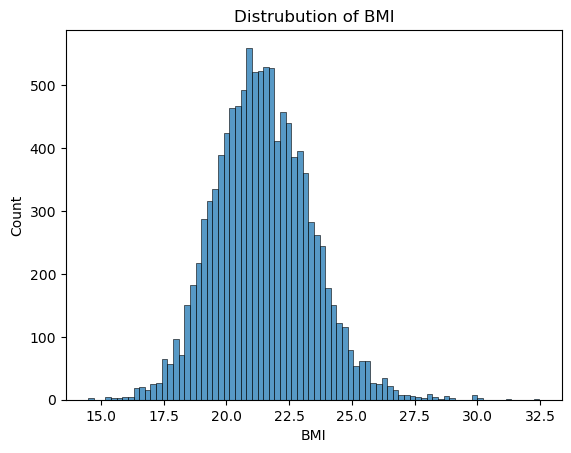

In [18]:
sns.histplot(olympics['BMI'])

plt.title('Distrubution of BMI')
plt.show()

Then, we try to visualize if there's any correlation using a linear regression plot as we did before. We notice that athletes with the highest or lowest BMI are less likely to have great performance, as none of those with BMI > 30 or < 16 won any medals. Also, notice the line of best fit here is more flat than the ones we saw before. 

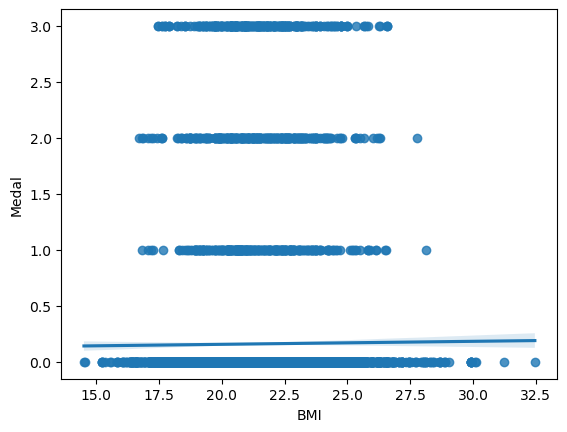

In [19]:
sns.regplot(x='BMI', y='Medal', data=olympics);

From the regression results, we can see the coefficient for BMI is 0.0027, which is smaller than smaller than both of the results we had previously. Additionally, notice the P-value for BMI is 0.369. This means that there is a 36.9% chance that this result is obtained by chance alone. Hence, we don't see any correlation between BMI and performance.

In [20]:
outcome_bmi, predictors_bmi = patsy.dmatrices('Medal ~ BMI', olympics)
model_bmi = sm.OLS(outcome_bmi, predictors_bmi)
res_bmi = model_bmi.fit()
print(res_bmi.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8067
Date:                Tue, 19 Mar 2024   Prob (F-statistic):              0.369
Time:                        20:59:00   Log-Likelihood:                -9918.1
No. Observations:               11050   AIC:                         1.984e+04
Df Residuals:                   11048   BIC:                         1.985e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1038      0.064      1.622      0.1

### Multivariate Regression Analysis of Height and Weight

Although we saw that there is positive correlation between height/weight and athlete's performance, this relationship is not seen in the BMI metric. We wonder why is that the case. To figure out, we will use a multivariate linear regression, which allows us to measure the effect of multiple predictors on the outcome.

In [21]:
outcome_hw, predictors_hw = patsy.dmatrices('Medal ~ Height + Weight', olympics)
model_hw = sm.OLS(outcome_hw, predictors_hw)
res_hw = model_hw.fit()
print(res_hw.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     18.76
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           7.37e-09
Time:                        20:59:00   Log-Likelihood:                -9899.8
No. Observations:               11050   AIC:                         1.981e+04
Df Residuals:                   11047   BIC:                         1.983e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5615      0.148     -3.787      0.0

From the result, we first notice the coefficient for height is 0.0042. This implies that for every 1 cm of height increased, the 'points' goes up for 0.0042 if holding the weight constant. On the other hand, we notice the coefficient for weight is -0.0002 and the P-value is 0.859, meaning there's a 85.9% chance that this result if obtained by random chance alone. Thus, we conclude that there is a positive correlation between height and performance, but no correlation between weight and performance is observed.

## Further Analysis in Sub-categories

Although we have determined that athlete's height correlates with their performance while their weight do not, let's dig further to see if this result differs in different sub groups. We will split up the athletes based on different events, distances and gender to see if we can find stronger correlation in these sub groups.

### Hurdles vs. Run

We will start by comparing athletes who competed in hurdles with those who competed in running events. First, we want to visualize the relationship between height/weight in different sub-groups and their performance. As we can observe below, the hurdle group tends to have wider spread in height than the run group; and both groups seem to have the same spread in weight. The overall trend seems to be slightly positive in all four groups.

Text(0.5, 0, 'Run Athletes Height')

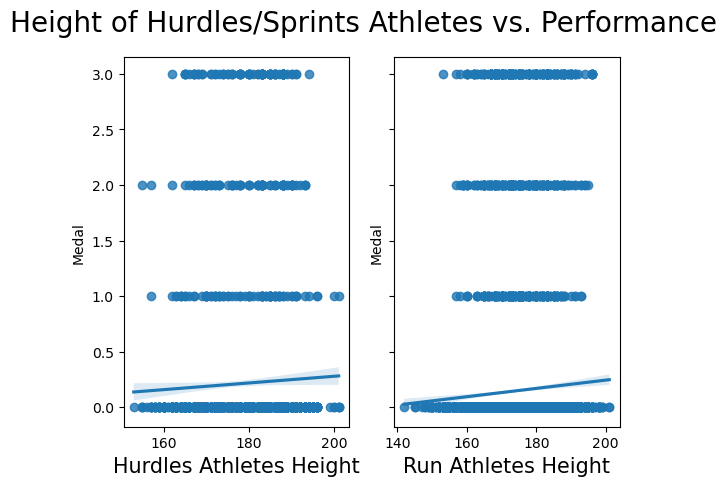

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
fig.suptitle('Height of Hurdles/Sprints Athletes vs. Performance', size=20)
sns.regplot(x='Height', y='Medal', data=olympics_hurdles, ax=ax1)
ax1.set_xlabel("Hurdles Athletes Height", size=15)

sns.regplot(x='Height', y='Medal', data=olympics_run, ax=ax2)
ax2.set_xlabel("Run Athletes Height", size=15)

Text(0.5, 0, 'Run Athletes Weight')

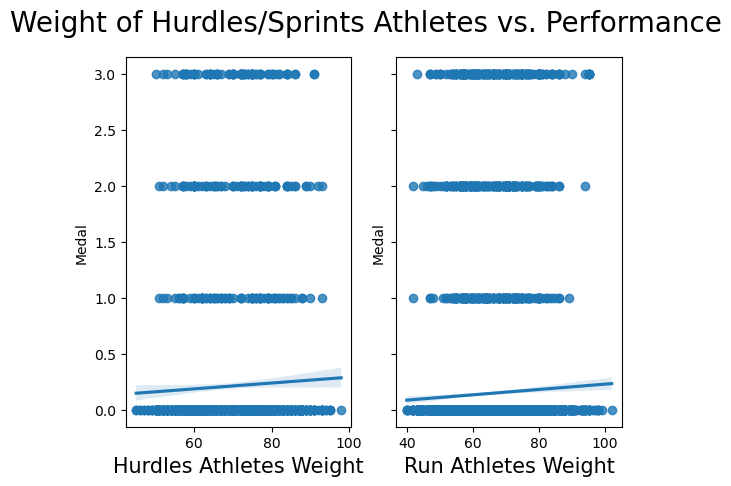

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
fig.suptitle('Weight of Hurdles/Sprints Athletes vs. Performance', size=20)
sns.regplot(x='Weight', y='Medal', data=olympics_hurdles, ax=ax1)
ax1.set_xlabel("Hurdles Athletes Weight", size=15)

sns.regplot(x='Weight', y='Medal', data=olympics_run, ax=ax2)
ax2.set_xlabel("Run Athletes Weight", size=15)

Let's check using regression to see if this is actually the case. From the regression results, we can notice that the P-value for Height in the hurdle group and Weight in both groups are quite high (>0.05). So, those results are not statistically significant. Other than that, the coefficient for Height in the running group is 0.0042, which is interestingly the same as the result we got in the entire dataset. Thus, we conclude that there is a positive correlation between height and performance only in the running group.

In [24]:
outcome_hurdle, predictors_hurdle = patsy.dmatrices('Medal ~ Height + Weight', olympics_hurdles)
model_hurdle = sm.OLS(outcome_hurdle, predictors_hurdle)
res_hurdle = model_hurdle.fit()
print(res_hurdle.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.852
Date:                Tue, 19 Mar 2024   Prob (F-statistic):              0.157
Time:                        20:59:01   Log-Likelihood:                -2328.9
No. Observations:                2279   AIC:                             4664.
Df Residuals:                    2276   BIC:                             4681.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2064      0.419     -0.492      0.6

In [25]:
outcome_run, predictors_run = patsy.dmatrices('Medal ~ Height + Weight', olympics_run)
model_run = sm.OLS(outcome_run, predictors_run)
res_run = model_run.fit()
print(res_run.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     13.19
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           1.91e-06
Time:                        20:59:01   Log-Likelihood:                -7511.4
No. Observations:                8771   AIC:                         1.503e+04
Df Residuals:                    8768   BIC:                         1.505e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5533      0.158     -3.506      0.0

### Short vs Long Distance

We continue our analysis by comparing athletes who competed in short distance vs. long distance. As usual, we start by creating visualizations of height/weight vs. performance in the two sub-groups. We notice that both height and weight have similar spread in both groups, but it appears that height may have a greater correlation when it comes to short distance events since the line of best fit for long distance seems to be flatter.

Text(0.5, 0, 'Athletes Height Long')

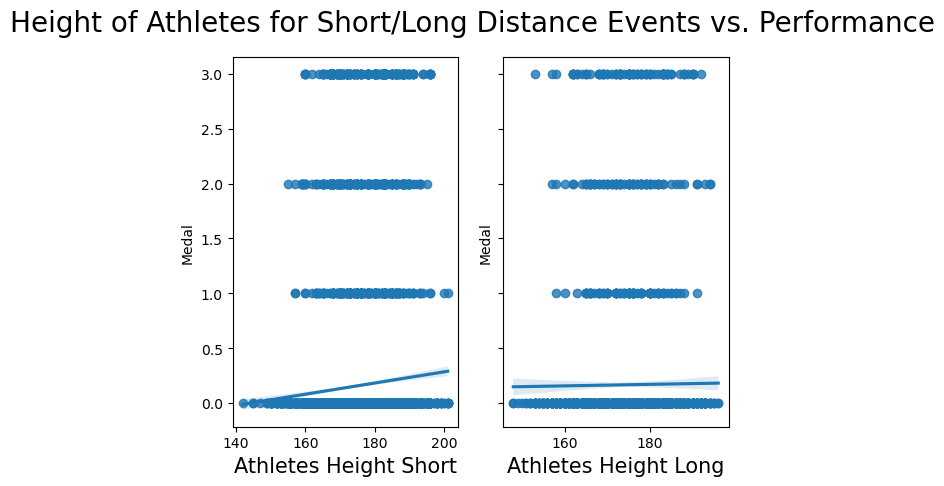

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
fig.suptitle('Height of Athletes for Short/Long Distance Events vs. Performance', size=20)
sns.regplot(x='Height', y='Medal', data=olympics_short, ax=ax1)
ax1.set_xlabel("Athletes Height Short", size=15)

sns.regplot(x='Height', y='Medal', data=olympics_long, ax=ax2)
ax2.set_xlabel("Athletes Height Long", size=15)

Text(0.5, 0, 'Athletes Weight Long')

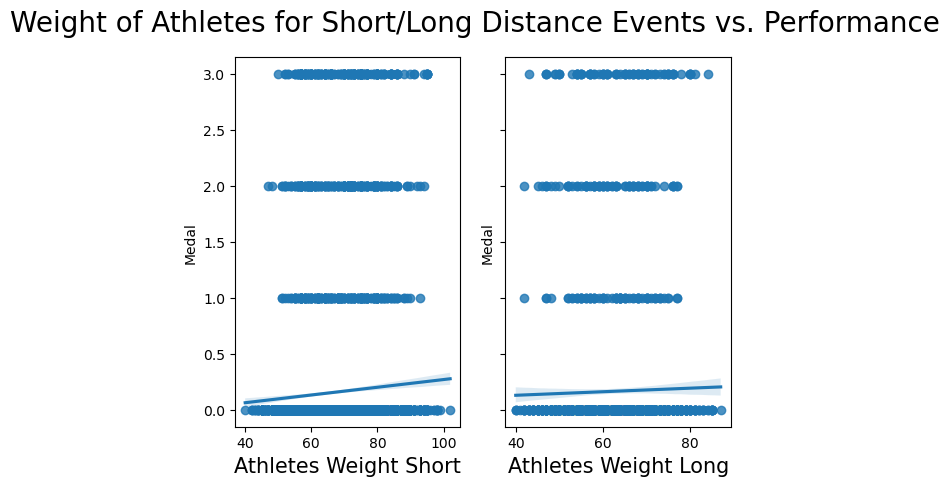

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
fig.suptitle('Weight of Athletes for Short/Long Distance Events vs. Performance', size=20)
sns.regplot(x='Weight', y='Medal', data=olympics_short, ax=ax1)
ax1.set_xlabel("Athletes Weight Short", size=15)

sns.regplot(x='Weight', y='Medal', data=olympics_long, ax=ax2)
ax2.set_xlabel("Athletes Weight Long", size=15)

From the regression results, we first observe that the P-value for Height in long distance and Weight in both groups are high (>0.05), which makes these results not statistically significant. We also notice that the coefficient for Height in the short distance group is 0.006. This is higher than any of the results we previously had. Hence, we can conclude that athlete's height correlates with their performance in a greater extent in short distance events. 

In [28]:
outcome_short, predictors_short = patsy.dmatrices('Medal ~ Height + Weight', olympics_short)
model_short = sm.OLS(outcome_short, predictors_short)
res_short = model_short.fit()
print(res_short.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     23.54
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           6.41e-11
Time:                        20:59:02   Log-Likelihood:                -7245.2
No. Observations:                8153   AIC:                         1.450e+04
Df Residuals:                    8150   BIC:                         1.452e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8281      0.173     -4.782      0.0

In [29]:
outcome_long, predictors_long = patsy.dmatrices('Medal ~ Height + Weight', olympics_long)
model_long = sm.OLS(outcome_long, predictors_long)
res_long = model_long.fit()
print(res_long.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9852
Date:                Tue, 19 Mar 2024   Prob (F-statistic):              0.373
Time:                        20:59:02   Log-Likelihood:                -2647.6
No. Observations:                2897   AIC:                             5301.
Df Residuals:                    2894   BIC:                             5319.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2972      0.307      0.966      0.3

### Male vs Female

Lastly, we compare athletes in different gender groups (only considered male and female here because dataset only contains these two). From the visualizations below, we can observe that the spread of height/weight in both groups are pretty similar, with the difference that the highest height and weight for male athletes are higher than those of female athletes. And the line of best fit all have a similar positive trend.

Text(0.5, 0, 'Female Athletes Height')

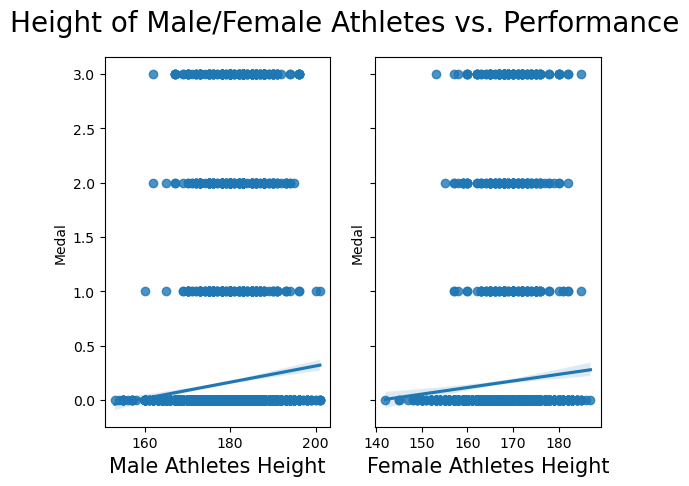

In [30]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
fig.suptitle('Height of Male/Female Athletes vs. Performance', size=20)
sns.regplot(x='Height', y='Medal', data=olympics_m, ax=ax1)
ax1.set_xlabel("Male Athletes Height", size=15)

sns.regplot(x='Height', y='Medal', data=olympics_f, ax=ax2)
ax2.set_xlabel("Female Athletes Height", size=15)

Text(0.5, 0, 'Female Athletes Weight')

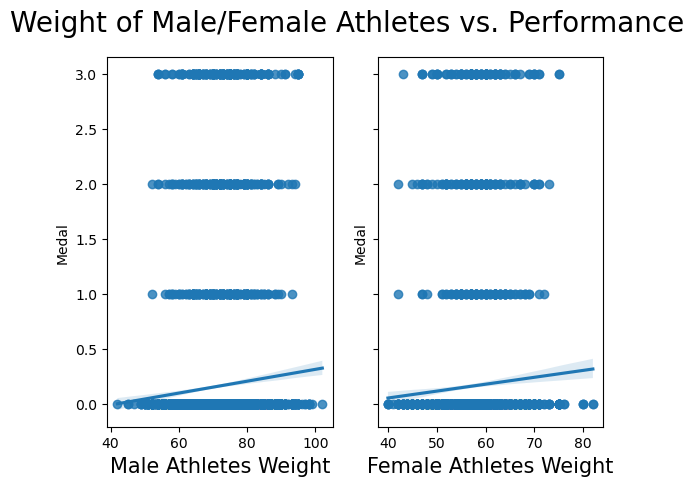

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
fig.suptitle('Weight of Male/Female Athletes vs. Performance', size=20)
sns.regplot(x='Weight', y='Medal', data=olympics_m, ax=ax1)
ax1.set_xlabel("Male Athletes Weight", size=15)

sns.regplot(x='Weight', y='Medal', data=olympics_f, ax=ax2)
ax2.set_xlabel("Female Athletes Weight", size=15)

From the regression results, we first notice the P-value for Height in the female group and Weight in both groups are high (>0.05), hence they are not statistically significant. On the other hand, the coefficient for Height in the male group is 0.0063. Notice this value is even higher than the one we had in the short distance group. This draws us to the conclusion that there is a strong correlation between male athlete's height and their performance. 

In [32]:
outcome_male, predictors_male = patsy.dmatrices('Medal ~ Height + Weight', olympics_m)
model_male = sm.OLS(outcome_male, predictors_male)
res_male = model_male.fit()
print(res_male.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     27.65
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           1.09e-12
Time:                        20:59:03   Log-Likelihood:                -6291.8
No. Observations:                7053   AIC:                         1.259e+04
Df Residuals:                    7050   BIC:                         1.261e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0797      0.200     -5.404      0.0

In [33]:
outcome_female, predictors_female = patsy.dmatrices('Medal ~ Height + Weight', olympics_f)
model_female = sm.OLS(outcome_female, predictors_female)
res_female = model_female.fit()
print(res_female.summary())

                            OLS Regression Results                            
Dep. Variable:                  Medal   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     9.027
Date:                Tue, 19 Mar 2024   Prob (F-statistic):           0.000123
Time:                        20:59:03   Log-Likelihood:                -3590.0
No. Observations:                3997   AIC:                             7186.
Df Residuals:                    3994   BIC:                             7205.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6971      0.277     -2.514      0.0

# Ethics & Privacy


In our project, we understand that there are several key considerations that we must take into account. To ensure the privacy of the athletes, the data is going to be anonymized, so that there aren’t any identifiers that can trace the data back to individual athletes. We will also need to assess and mitigate any biases in our dataset. This involves examining the demographics in the data so that specific populations are not overrepresented or vice versa, as this could skew the results. For example, if our dataset mainly focuses on athletes from certain countries or doesn't consider the athletes from less represented countries, this could lead to biased results. We plan to establish guidelines for identifying potential biases during our analysis. We will be careful in how we communicate our findings, ensuring that we do not promote stereotypes or suggest that physical attributes are the sole determinants of athletic success. Any other issues related to data privacy and equitable impact will be carefully considered and addressed. If we identify such issues, we will handle them by adjusting our approach and communicating these ethical issues when we share our study's findings.

# Discussion and Conclusion


From analysis of the three physical attributes of Height, Weight, and BMI we found that Weight and BMI have no correlation to the performance of an athelete. Interestingly, we found a slight positive correlation betwee Height and performance. From there we dug deeping to consider the sub-categories to see if we can gather any more insights or stronger correlations. We found a similar slight positive correlation between height and performance in the sprint group over the hurdlers group. Furthermore, we also found that there was a stronger correlation between height and performance in the short distance and male group suggesting the height has more influence on performance with these categories in mind. Taking this into consideration it might be useful to consider these interdependencies for future studies. 

Comparing with the past research done in this field as mentioned earlier, we did find height as a decent indicator of physical attributes towards performance. However, it is important to note that this study had better metrics for performance since they had conducted the study themselves on Japansese college athletes (Aikawa et al). Furthermore, similiar to the methods done in both articles mentioned, regression analysis was key in learning more about the correlation between the two. 

## Limitations and Moving Forward

One of the limitations that we had come across was the data for the performance metrics. In our ideal datasets we mentioned that it would be beneficial to have information such as track time as that is more of a clearer performance metric that has more variability compared to the metric based on winning a medal. Having N/A medal suggests that the athlete can place anywhere after 3rd place which groups a large amount of athletes together when in reality they most probably have differences in performance. 

Another limitation was that in the dataset the name used for the athlete was not symmetric. To clarify, we had actually found a dataset that provided track times of Olympic athletes but it did not include physical attributes such as height and weight. We had hoped to merge the datasets by the athlete names but there were many discrepancies on the names of the athletes that made it too hard to merge together accurately. This is why we ended up having to focus on the singular Olympic dataset and use the medals as our primary performance metric.

Despite these limitations in our data collection, using the OLS regression model became crucial for our analysis for our study.

Moving forward, if we can find more datasets that have metrics for the performance whether it be in track times of overall sucess as an individual over the years (since the same athlete may compete again) could potentially find better correlations for this area of study.

Furthermore, since this study only focus on track sporting events, there is room to perform analysis on much more! The Olympic dataset used has a plethora of data and includes data from various different sports. A similar regression analysis study can be performed comparing the physical attributes to the performance of an athlete but for different sports. 

In conclusion, this study laid a basic groundwork to exploring the Olympic history dataset. There was much needed cleaning to be done but the basis of the dataset which includes athlete physical attributes and their respective sporting events can be very useful towards future studies on physical attributes relating to performance.

# Team Contributions

- Hieu Pham
    * Contributed to Research Question. Conducted and analyzed regression analysis on height attribute. Contributed to the organization of meetings and distribution of tasks. Wrote part of background.
- Rishi Munagala
    * Contributed to Research Question. Wrote background past research section. Conducted and analyzed regression analysis on weight attribute. Wrote limitations and moving forward section along with part of the conclusion. 
- Mingyang Chen
    * Contributed to Hypothesis. Wrote code for data cleaning. Conducted and analyzed regression analysis on BMI attribute, multivariate regression, and regression in sub-categories.
- Henry Than
    * Contributed to ethical considerations of project. Helped ensure the integrity of the research identifying and addressing potential biases.
